<a href="https://colab.research.google.com/github/IdrisJunaidAI/FlowPilot-QA/blob/main/L09_IdrisJunaid_ITAI1371.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 09 Lab: Ensemble Methods

**Student:** Idris Junaid  
**Course:** ITAI 1371

**Objective:** Learn how ensemble methods combine several individual models to produce predictions that can be more accurate and robust than predictions from one model alone.


## Part 1: The Wisdom of the Crowd

The main idea behind ensemble methods is the wisdom of the crowd. Instead of relying on one model, an ensemble combines predictions from a group of models.

* **Bagging:** Trains multiple models on different random samples and combines their predictions. Random Forest is a well known bagging method.
* **Boosting:** Builds models sequentially, with each new model focusing more attention on errors made by earlier models.


## Part 2: Setup

This lab uses the Iris dataset to classify flowers into three species based on four measured features.


In [1]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load the Iris features and target labels.
iris = load_iris()
X = iris.data
y = iris.target

# Reserve 30 percent of the data for an unbiased final comparison.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f'Training samples: {len(X_train)}')
print(f'Test samples: {len(X_test)}')


Training samples: 105
Test samples: 45


## Part 3: A Single Decision Tree

A Decision Tree can create detailed decision rules, but a single tree may overfit its training data. The first task establishes a baseline model for comparison.


In [2]:
# Create and train one Decision Tree as the baseline model.
single_tree = DecisionTreeClassifier(random_state=42)
single_tree.fit(X_train, y_train)

# Predict the test labels and calculate classification accuracy.
y_pred_tree = single_tree.predict(X_test)
accuracy_tree = accuracy_score(y_test, y_pred_tree)
print(f'Accuracy of a single Decision Tree: {accuracy_tree:.2%}')


Accuracy of a single Decision Tree: 100.00%


## Part 4: The Random Forest Ensemble

A Random Forest combines many Decision Trees. Each tree is trained with randomness in the observations and features it considers. The forest uses majority voting for classification, which can reduce the instability and variance of one tree.


In [3]:
# Train an ensemble containing 100 Decision Trees.
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(X_train, y_train)

# Evaluate the forest on the same test set used for the baseline.
y_pred_rf = random_forest.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f'Accuracy of the Random Forest: {accuracy_rf:.2%}')

# Report the direct difference in accuracy between both models.
difference = accuracy_rf - accuracy_tree
print(f'Random Forest accuracy difference: {difference:+.2%}')


Accuracy of the Random Forest: 100.00%
Random Forest accuracy difference: +0.00%


## Part 5: Feature Importance

Tree based ensembles estimate how much each feature contributes to reducing uncertainty across the fitted trees. The following plot compares these relative importance values.


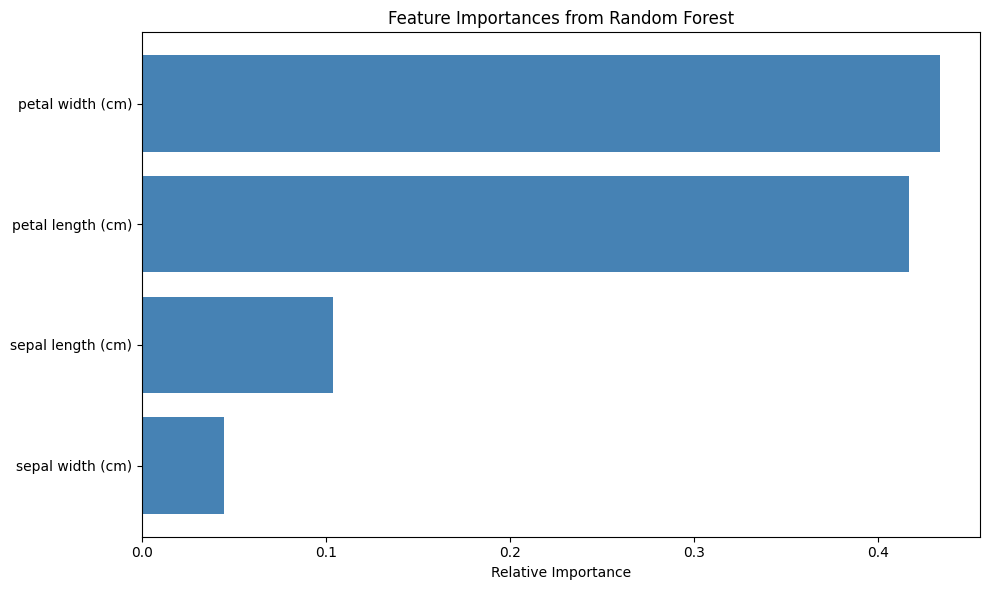

petal width (cm): 0.4340
petal length (cm): 0.4173
sepal length (cm): 0.1041
sepal width (cm): 0.0446


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Extract feature importance values learned by the trained forest.
importances = random_forest.feature_importances_
feature_names = iris.feature_names
indices = np.argsort(importances)

# Plot features from the least important to the most important.
plt.figure(figsize=(10, 6))
plt.title('Feature Importances from Random Forest')
plt.barh(range(len(indices)), importances[indices], color='steelblue', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

# Print exact values to support interpretation of the plot.
for index in indices[::-1]:
    print(f'{feature_names[index]}: {importances[index]:.4f}')


## Knowledge Check and Reflection

### 1. What is the main idea behind ensemble methods?

An ensemble combines the predictions of several models to make one final decision. A committee is often more dependable than one model because individual errors can balance one another when the models learn somewhat different patterns. In a Random Forest, many trees vote on the predicted class. This reduces dependence on the unusual rules or errors of any single tree and usually creates a more stable model.

### 2. Which model performed better, and was this expected?

Both the single Decision Tree and the Random Forest achieved 100.00% accuracy on this particular test split, so neither model performed better according to test accuracy. The tie is reasonable because the Iris dataset is small and its species are strongly separated by some features. I expected the Random Forest to be at least as accurate and generally more stable, but ensemble methods do not guarantee a higher score on every individual split. The equal result also shows why one test split is not enough to claim that two models will always perform equally.

### 3. Which two features were most important?

Petal length and petal width were the two most important features in the Random Forest. Their importance values were much larger than those of sepal length and sepal width. This result makes practical sense because differences in petal size provide strong visual information for distinguishing the Iris species represented in the dataset.

### Reflection

This lab helped me understand that ensemble learning is not simply about adding more models. Its value comes from combining diverse models so that the final prediction is less dependent on the weaknesses of one model. I initially expected the Random Forest to produce a visibly higher accuracy, but the equal scores reminded me to interpret results within the limits of the dataset and test split. I also learned that feature importance makes a complex ensemble easier to interpret by showing which measurements influenced its decisions most. My main takeaway is that model comparison should consider stability, generalization, and interpretability in addition to one accuracy value.
